# Precision Irrigation: From Data to Prediction

## The Goal
The objective of this project is to build a system that automatically decides if a crop needs water based on environmental and soil sensors. This reduces water waste and ensures optimal crop health.

## The Data
We are using `irrigation_prediction.csv`, which contains:
- **Sensors:** Soil Moisture, Temperature, Humidity, Rainfall, Sunlight Hours, etc.
- **Context:** Crop type, Soil type, Growth stage, Season, Region, etc.
- **Target:** `Irrigation_Need` (Low, Medium, High).

### Step 1: Import Libraries
We need `pandas` for data handling, `seaborn/matplotlib` for visuals, and `sklearn/xgboost` for the AI models.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    ConfusionMatrixDisplay, roc_curve, auc
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

DATA_PATH = "Datasets/train_val_dataset.csv"\nMODEL_PATH = "best_irrigation_model.pkl"
SCALER_PATH = "data_scaler.pkl"

### Step 2: Load and Inspect Data
Before building a model, we must "meet" our data. We check for missing values and look at the first few rows.

In [2]:
def load_data(file_path):
    if not os.path.exists(file_path):
        print(f"Error: {file_path} not found.")
        return None
    df = pd.read_csv(file_path)
    df = df.dropna() # Remove any empty rows
    print(f"Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    return df

df = load_data(DATA_PATH)
df.head()

Data Loaded: 9000 rows, 20 columns


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,7.18,28.52,0.80,0.63,40.14,53.99,1282.96,8.91,18.75,Cotton,Vegetative,Kharif,Sprinkler,Reservoir,14.53,Yes,24.39,West,Medium
1,Loamy,6.96,32.66,1.18,3.21,16.08,59.57,430.00,7.47,11.39,Rice,Harvest,Kharif,Canal,River,1.11,Yes,7.48,Central,Low
2,Loamy,8.09,48.61,0.44,1.57,14.93,64.41,250.68,5.72,3.19,Wheat,Flowering,Rabi,Canal,Groundwater,7.55,Yes,91.36,North,Medium
3,Clay,7.36,46.95,0.89,1.19,30.44,40.69,1920.00,6.72,17.56,Cotton,Vegetative,Zaid,Drip,River,12.44,No,72.07,South,Medium
4,Silt,5.95,33.47,0.61,1.39,29.89,75.28,1603.16,9.91,16.58,Cotton,Harvest,Zaid,Sprinkler,Reservoir,6.11,Yes,56.90,West,Low


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                9000 non-null   str    
 1   Soil_pH                  9000 non-null   float64
 2   Soil_Moisture            9000 non-null   float64
 3   Organic_Carbon           9000 non-null   float64
 4   Electrical_Conductivity  9000 non-null   float64
 5   Temperature_C            9000 non-null   float64
 6   Humidity                 9000 non-null   float64
 7   Rainfall_mm              9000 non-null   float64
 8   Sunlight_Hours           9000 non-null   float64
 9   Wind_Speed_kmh           9000 non-null   float64
 10  Crop_Type                9000 non-null   str    
 11  Crop_Growth_Stage        9000 non-null   str    
 12  Season                   9000 non-null   str    
 13  Irrigation_Type          9000 non-null   str    
 14  Water_Source             9000 non-n

### Step 3: Identify Features and Target
We need to tell the computer which columns are the "Questions" (Features) and which is the "Answer" (Target).

In [4]:
feature_cols = [
    'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 
    'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 
    'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 
    'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region'
]
target_col = "Irrigation_Need"

print(f"Features: {feature_cols}")
print(f"Target: {target_col}")

Features: ['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region']
Target: Irrigation_Need


### Step 4: Categorical Encoding
Machine Learning models only understand numbers. We convert text like "Wheat" or "Black Soil" into numbers (0, 1, 2...).

In [5]:
label_encoders = {}
print("--- Category Mappings ---")
for col in feature_cols + [target_col]:
    if df[col].dtype == "object" or df[col].dtype == "str" or pd.api.types.is_string_dtype(df[col]):
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        
        # Print the mapping clearly
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"{col}: {mapping}")

df.tail()

--- Category Mappings ---
Soil_Type: {'Clay': np.int64(0), 'Loamy': np.int64(1), 'Sandy': np.int64(2), 'Silt': np.int64(3)}
Crop_Type: {'Cotton': np.int64(0), 'Maize': np.int64(1), 'Potato': np.int64(2), 'Rice': np.int64(3), 'Sugarcane': np.int64(4), 'Wheat': np.int64(5)}
Crop_Growth_Stage: {'Flowering': np.int64(0), 'Harvest': np.int64(1), 'Sowing': np.int64(2), 'Vegetative': np.int64(3)}
Season: {'Kharif': np.int64(0), 'Rabi': np.int64(1), 'Zaid': np.int64(2)}
Irrigation_Type: {'Canal': np.int64(0), 'Drip': np.int64(1), 'Rainfed': np.int64(2), 'Sprinkler': np.int64(3)}
Water_Source: {'Groundwater': np.int64(0), 'Rainwater': np.int64(1), 'Reservoir': np.int64(2), 'River': np.int64(3)}
Mulching_Used: {'No': np.int64(0), 'Yes': np.int64(1)}
Region: {'Central': np.int64(0), 'East': np.int64(1), 'North': np.int64(2), 'South': np.int64(3), 'West': np.int64(4)}
Irrigation_Need: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
8995,3,5.49,51.27,1.37,1.61,27.06,56.13,2093.61,5.90,4.08,3,3,1,3,0,0.78,1,79.83,3,1
8996,1,5.09,29.55,0.40,0.87,36.26,63.06,106.38,8.11,8.82,2,0,1,1,0,12.05,1,24.93,2,2
8997,2,5.10,53.84,0.92,2.34,15.24,35.98,2165.18,7.88,9.35,2,0,2,1,0,1.60,0,64.39,4,1
8998,1,6.59,25.67,1.15,1.09,16.46,28.51,2406.79,9.95,1.40,5,0,0,3,0,6.31,1,67.66,1,1
8999,2,5.53,37.13,1.35,0.35,34.86,82.75,1614.44,4.54,14.89,5,0,1,2,1,9.53,0,117.52,0,2


### Step 5: Exploratory Data Analysis (EDA)
Visualizing patterns. For example: Does a higher temperature correlate with the need for irrigation?

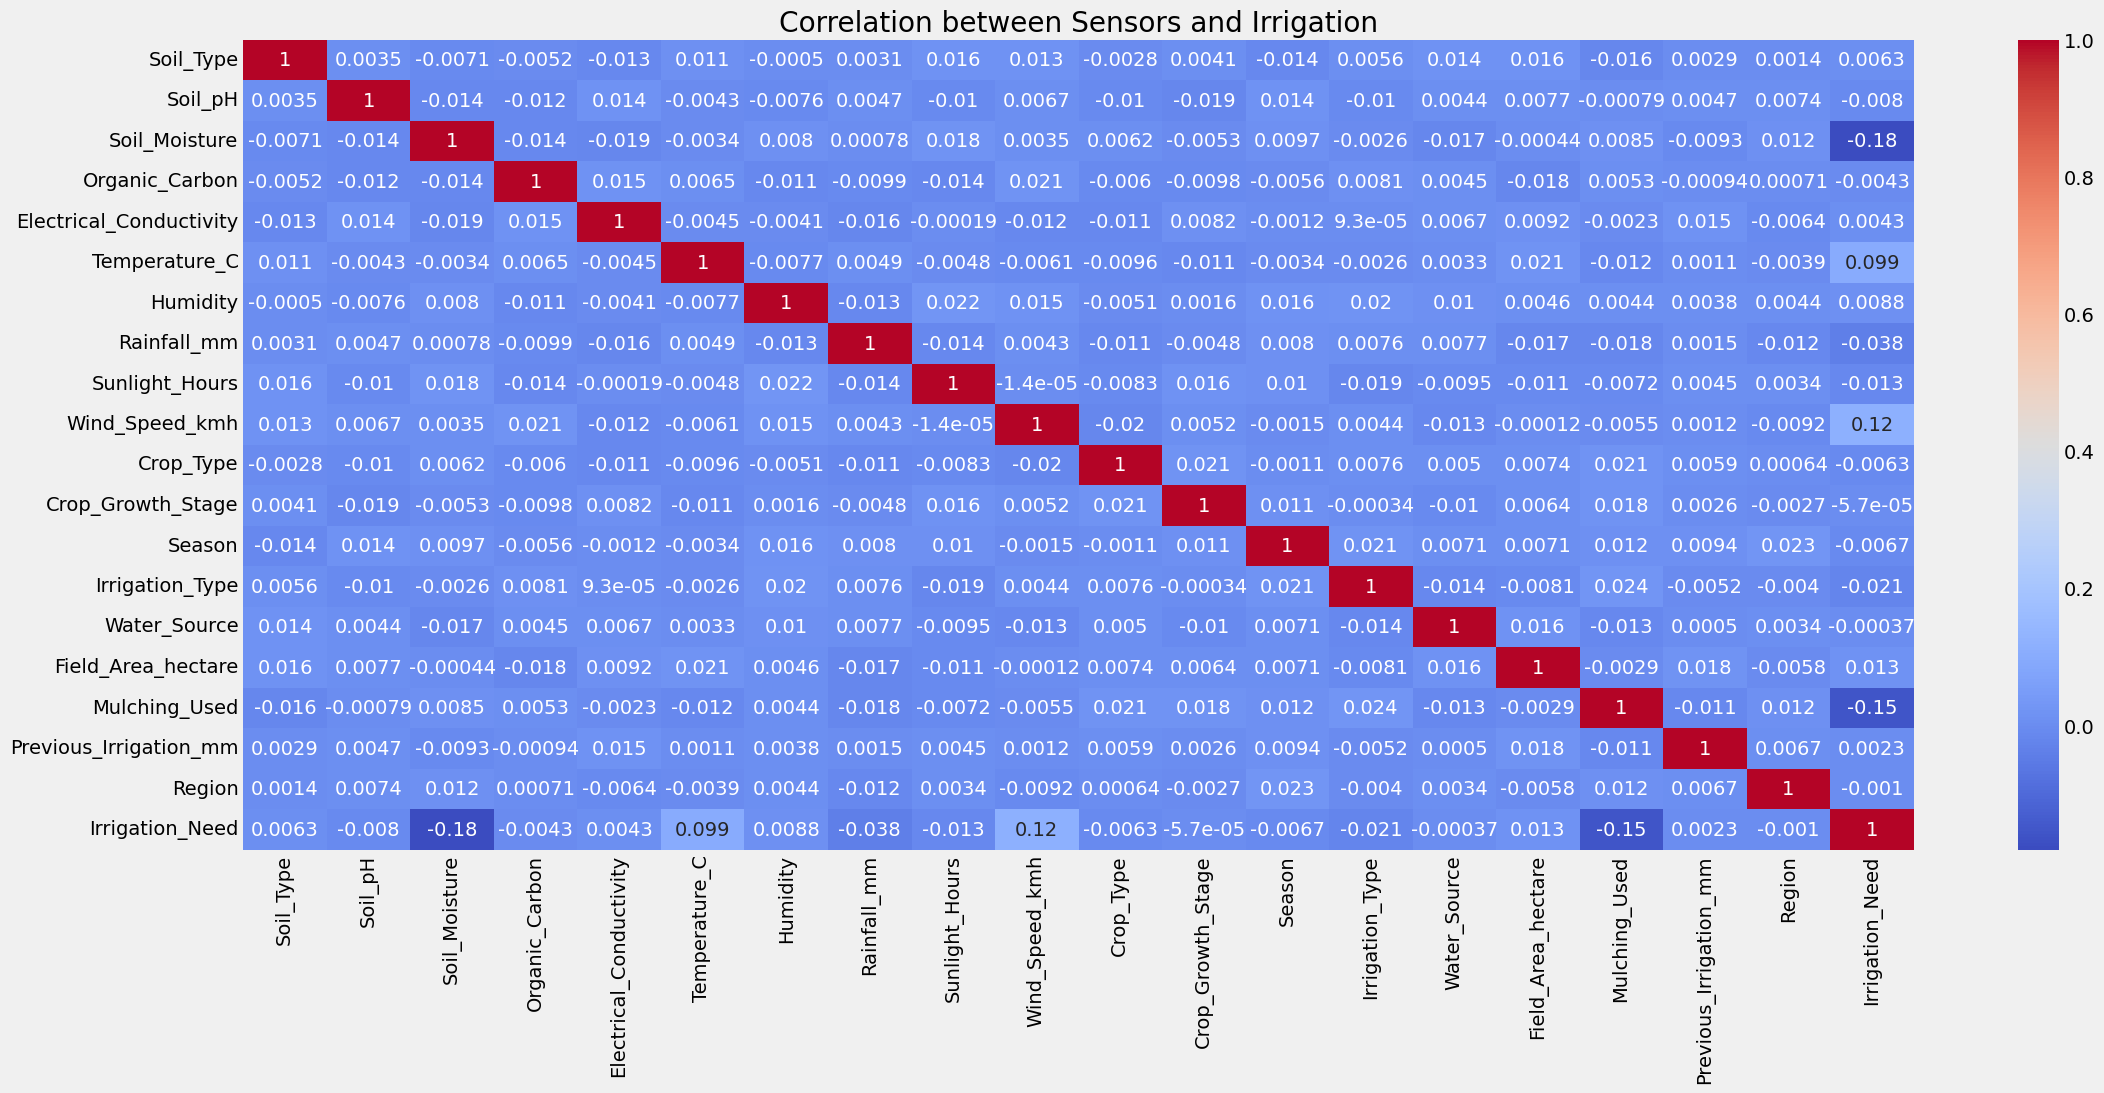

In [18]:
def perform_eda(df, feature_cols, target_col):
    # 1. Correlation Heatmap
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(24, 10))
    sns.heatmap(df[feature_cols + [target_col]].corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation between Sensors and Irrigation")
    plt.show()

    # 2. Distribution of Moisture (MOI)
    if "MOI" in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(data=df, x="MOI", hue=target_col, kde=True)
        plt.title("Moisture Levels vs Irrigation Need")
        plt.show()

perform_eda(df, feature_cols, target_col)

### Step 6: Preprocessing (Splitting & Scaling)
1. **Split:** We hide 20% of the data from the AI to test it later.
2. **Scale:** We put all numbers on a similar scale (e.g., 0 to 1) so a high temperature doesn't "outweigh" a small moisture change just because the number is bigger.

In [7]:
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully.")

Data split and scaled successfully.


### Step 7: Training & Hyperparameter Tuning
We try different "brains" (Random Forest, KNN, XGBoost) and find which settings work best for this specific data.

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

def train_models(X_train, y_train):
    # We add class_weight='balanced' to prioritize rare/critical classes (High Need)
    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
        "XGBoost": XGBClassifier(eval_metric="logloss", n_jobs=-1),
        "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1),
        "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
        "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
    }
    
    trained_models = {}
    for name, model in models.items():
        print(f"Training {name} (Safety-Aware Mode)...")
        model.fit(X_train, y_train)
        trained_models[name] = model
    return trained_models

models = train_models(X_train_scaled, y_train)

Training Random Forest (Safety-Aware Mode)...
Training XGBoost (Safety-Aware Mode)...
Training KNN (Safety-Aware Mode)...
Training Decision Tree (Safety-Aware Mode)...
Training Neural Network (Safety-Aware Mode)...


### Step 8: Evaluation
How well did we do? We use a "Confusion Matrix" to see where the models got confused.


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.47      0.64        60
           1       0.99      1.00      0.99      1056
           2       0.95      0.99      0.97       684

    accuracy                           0.98      1800
   macro avg       0.98      0.82      0.87      1800
weighted avg       0.98      0.98      0.97      1800



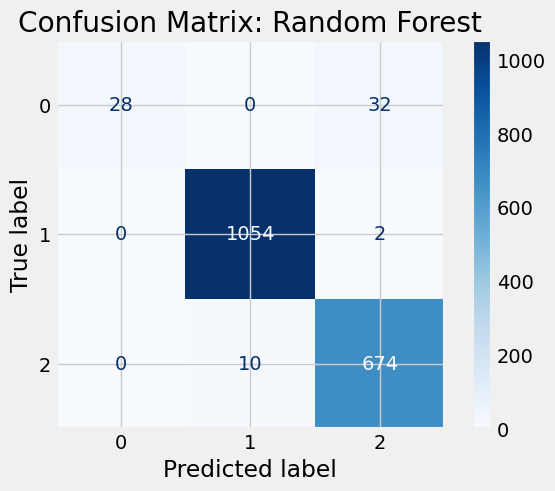


--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        60
           1       0.99      1.00      1.00      1056
           2       1.00      0.99      0.99       684

    accuracy                           0.99      1800
   macro avg       1.00      0.98      0.99      1800
weighted avg       0.99      0.99      0.99      1800



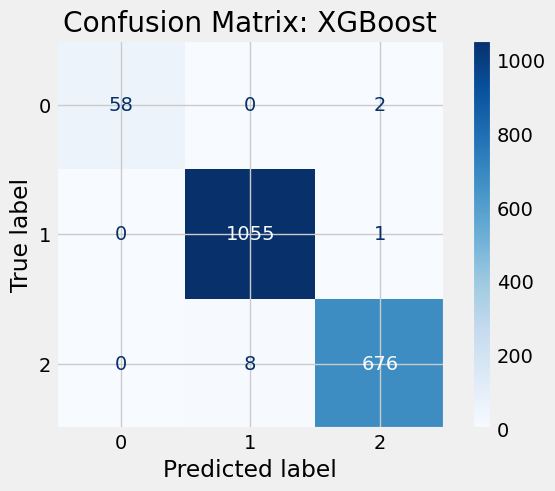


--- KNN Classification Report ---
              precision    recall  f1-score   support

           0       0.56      0.08      0.14        60
           1       0.73      0.87      0.79      1056
           2       0.66      0.52      0.58       684

    accuracy                           0.71      1800
   macro avg       0.65      0.49      0.51      1800
weighted avg       0.70      0.71      0.69      1800



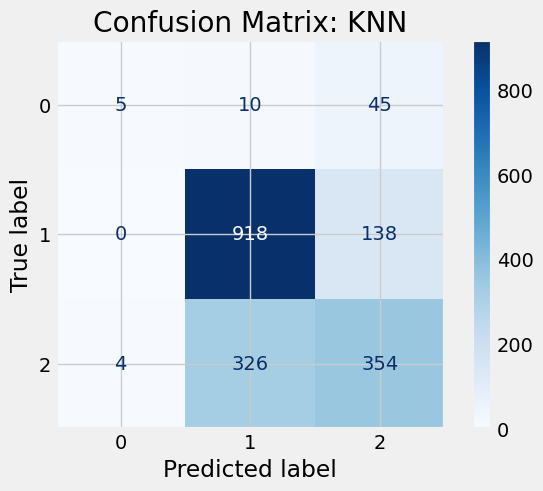


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.55      0.97      0.70        60
           1       0.91      0.86      0.88      1056
           2       0.78      0.81      0.79       684

    accuracy                           0.84      1800
   macro avg       0.75      0.88      0.79      1800
weighted avg       0.85      0.84      0.84      1800



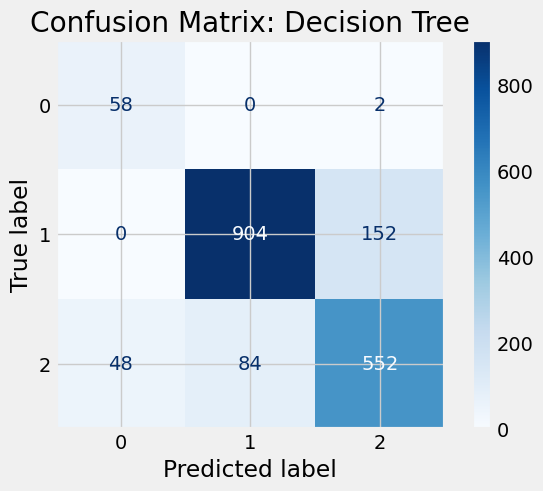


--- Neural Network Classification Report ---
              precision    recall  f1-score   support

           0       0.73      0.58      0.65        60
           1       0.92      0.94      0.93      1056
           2       0.87      0.86      0.86       684

    accuracy                           0.90      1800
   macro avg       0.84      0.79      0.81      1800
weighted avg       0.89      0.90      0.90      1800



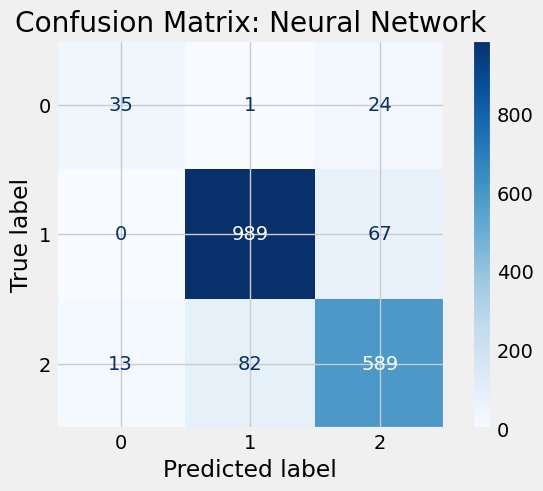

In [25]:
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

### Step 8.1: Advanced Multi-Class Interpretation
Since our irrigation has 3 levels, a standard matrix can be hard to read. Here, we use **Normalization** to show percentages (0.0 to 1.0) and add **Labels** to clearly see which level is which.

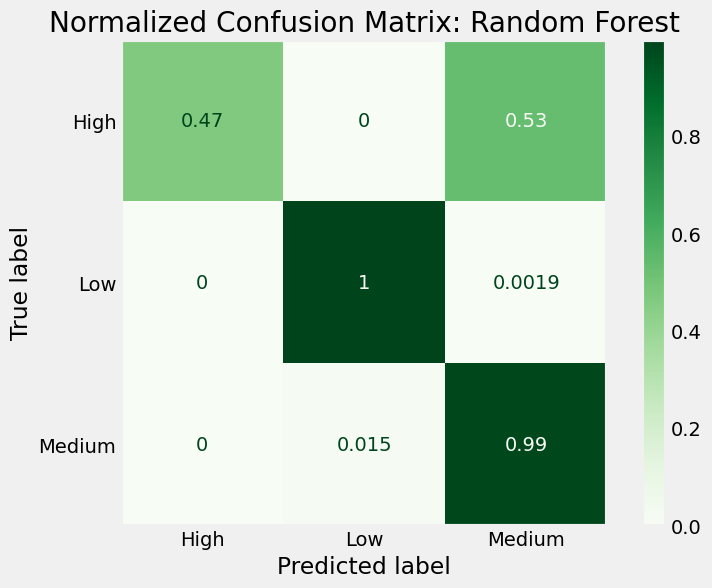

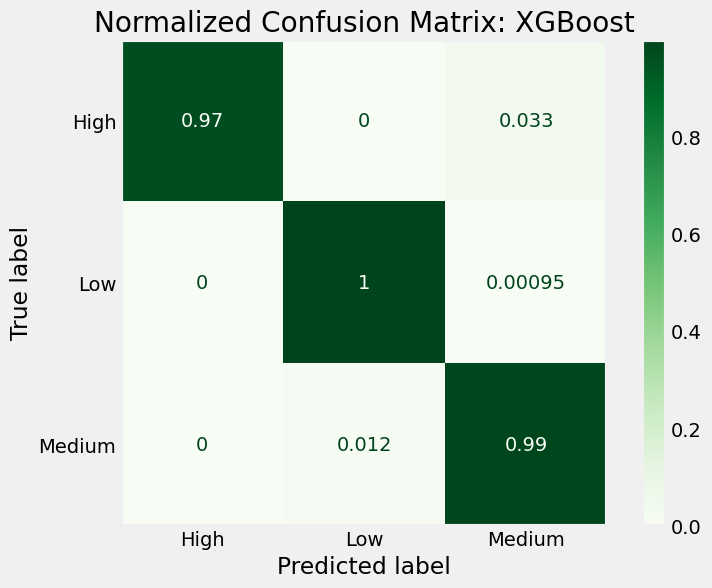

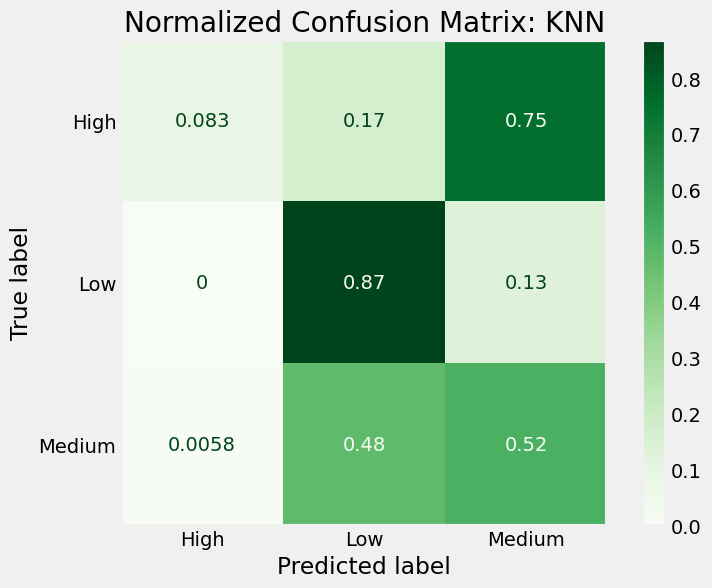

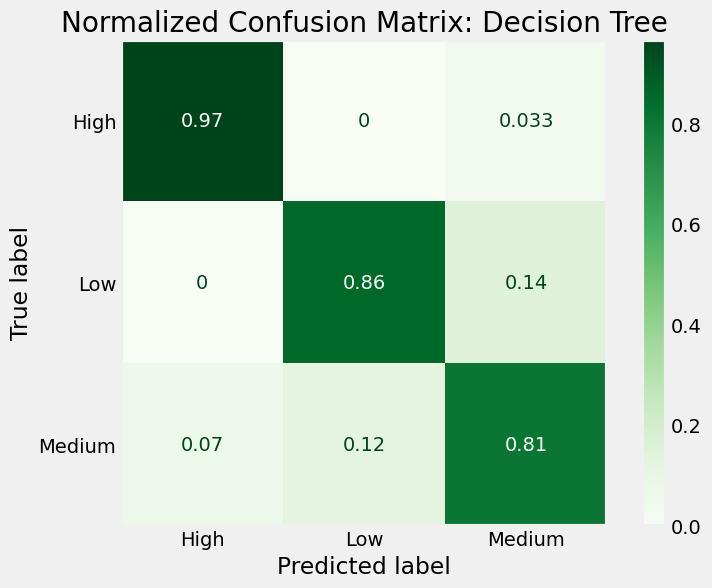

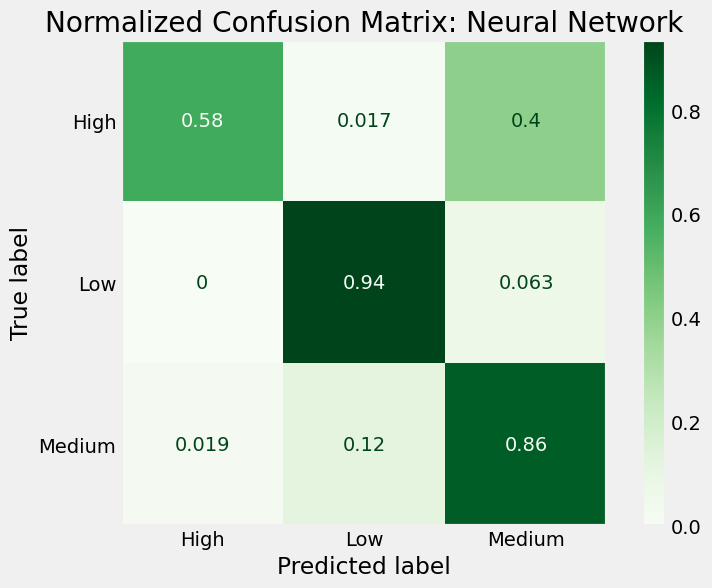

In [26]:
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    # Labels based on alphabetical sorting of Irrigation_Need
    disp_labels = ["High", "Low", "Medium"]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, 
        display_labels=disp_labels,
        cmap="Greens", 
        normalize='true', 
        ax=ax
    )
    plt.title(f"Normalized Confusion Matrix: {name}")
    plt.grid(False) 
    plt.show()

### Step 8.2: The Industry Leaderboard
To choose the winner, we compare the **F1-Score** (Balance) and **Recall** (Safety). In irrigation, High Recall for the 'High Water' class is the priority to prevent crop death.

In [27]:
from sklearn.metrics import f1_score, recall_score, accuracy_score
import pandas as pd

results_data = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    results_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 (Macro)": f1_score(y_test, y_pred, average='macro'),
        "Recall (Safety)": recall_score(y_test, y_pred, average='weighted')
    })

leaderboard = pd.DataFrame(results_data).sort_values(by="F1 (Macro)", ascending=False)
print("--- MODEL LEADERBOARD ---")
display(leaderboard)

--- MODEL LEADERBOARD ---


,Model,Accuracy,F1 (Macro),Recall (Safety)
1,XGBoost,0.993889,0.990244,0.993889
0,Random Forest,0.975556,0.866365,0.975556
4,Neural Network,0.896111,0.813765,0.896111
3,Decision Tree,0.841111,0.792527,0.841111
2,KNN,0.709444,0.506528,0.709444


### Step 9: Feature Testing (Multi-Model Ablation Study)
We re-train **all 5 models** without suspicious features (`Irrigation_Type`, `Water_Source`, `Previous_Irrigation_mm`) to ensure they can make smart decisions using only IoT sensors.

In [28]:
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

features_to_remove = ['Irrigation_Type', 'Water_Source', 'Previous_Irrigation_mm']
ablated_features = [c for c in feature_cols if c not in features_to_remove]

X_ablated = df[ablated_features]
X_train_ab, X_test_ab, y_train_ab, y_test_ab = train_test_split(
    X_ablated, y, test_size=0.2, random_state=42, stratify=y
)
scaler_ab = StandardScaler()
X_train_ab_scaled = scaler_ab.fit_transform(X_train_ab)
X_test_ab_scaled = scaler_ab.transform(X_test_ab)

models_to_test = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric="logloss", n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

ablated_results = []
for name, model in models_to_test.items():
    model.fit(X_train_ab_scaled, y_train_ab)
    y_pred_ab = model.predict(X_test_ab_scaled)
    f1_ab = f1_score(y_test_ab, y_pred_ab, average='macro')
    f1_baseline = leaderboard[leaderboard['Model'] == name]['F1 (Macro)'].values[0]
    ablated_results.append({"Model": name, "Baseline F1": f1_baseline, "Ablated F1": f1_ab, "Drop": f1_baseline - f1_ab})

display(pd.DataFrame(ablated_results).sort_values(by="Ablated F1", ascending=False))

,Model,Baseline F1,Ablated F1,Drop
1,XGBoost,0.990244,0.990244,0.000000
0,Random Forest,0.866365,0.969191,-0.102826
4,Neural Network,0.813765,0.828418,-0.014653
3,Decision Tree,0.792527,0.778137,0.014389
2,KNN,0.506528,0.585818,-0.079289


### Step 10: Multi-Model External Validation
Testing **all 5 ablated models** on a completely different dataset to find the most transferable 'Brain' for our IoT system.

In [29]:
NEW_DATA_PATH = "Datasets/blind_test_dataset.csv"\nif os.path.exists(NEW_DATA_PATH):
    new_df = pd.read_csv(NEW_DATA_PATH)
    for col, le in label_encoders.items():
        if col in new_df.columns: new_df[col] = le.transform(new_df[col].astype(str))
    
    X_new_scaled = scaler_ab.transform(new_df[ablated_features])
    y_new = new_df[target_col]
    
    for name, model in models_to_test.items():
        print(f"\n--- External Validation: {name} ---")
        print(classification_report(y_new, model.predict(X_new_scaled)))


--- External Validation: Random Forest ---
              precision    recall  f1-score   support

           0       1.00      0.70      0.82        33
           1       0.99      1.00      1.00       586
           2       0.97      0.99      0.98       381

    accuracy                           0.99      1000
   macro avg       0.99      0.90      0.93      1000
weighted avg       0.99      0.99      0.99      1000


--- External Validation: XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00       586
           2       1.00      1.00      1.00       381

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- External Validation: KNN ---
              precision    recall  f1-score   support

           0       0.33      0.09      0.14        33
           1 

### Step 11: Real-Time IoT Simulation & Multi-Model Consensus
This cell simulates a day in the field using **Ablated Models** (trained on 16 features). It generates practical sensor data and uses a **Voting System** (RF, XGB, KNN, DT, MLP) to determine the irrigation level.

In [30]:
import time
import numpy as np
from collections import Counter

def simulate_smart_farm_day(crop_name='Wheat'):
    print(f"--- STARTING 24-HOUR IoT SIMULATION FOR {crop_name.upper()} ---")
    print("Consensus Engine: [RF, XGB, KNN, DT, MLP] | Mode: HARD VOTING\n")
    
    # Reverse mapping for status printing
    status_map = {0: "HIGH", 1: "LOW", 2: "MEDIUM"}
    
    # We simulate 8 readings throughout the day (6 AM to 8 PM)
    for hour in range(6, 22, 2):
        # 1. GENERATE PRACTICAL DATA TRENDS
        hour_progress = (hour - 6) / 16.0 
        temp = 20 + (15 * np.sin(np.pi * hour_progress)) 
        moi = 60 - (40 * np.sin(np.pi * hour_progress)) 
        humidity = 80 - (30 * np.sin(np.pi * hour_progress))
        
        # 2. PREPARE FEATURE VECTOR (16 ablated features)
        sample_row = X_test_ab.iloc[[0]].copy()
        sample_row['Soil_Moisture'] = moi
        sample_row['Temperature_C'] = temp
        sample_row['Humidity'] = humidity
        
        # 3. MULTI-MODEL VOTING (Using ablated models dictionary from Step 13)
        input_scaled = scaler_ab.transform(sample_row)
        votes = []
        for name, model in models_to_test.items():
            pred = model.predict(input_scaled)[0]
            votes.append(pred)
        
        # 4. DECIDE BY CONSENSUS (Majority wins)
        consensus_pred = Counter(votes).most_common(1)[0][0]
        final_status = status_map.get(consensus_pred, "UNKNOWN")
        
        print(f"[{hour:02d}:00] Sensors -> Moi: {moi:.1f}% | Temp: {temp:.1f}C | Hum: {humidity:.1f}%")
        print(f"       >>> AI CONSENSUS: {final_status} (Votes: {dict(Counter([status_map[v] for v in votes]))})")
        
        if final_status == "HIGH":
            print("       ACTION: [!!!] Activating Emergency Irrigation")
        elif final_status == "MEDIUM":
            print("       ACTION: [OK] Normal Watering Schedule")
        else:
            print("       ACTION: [Snooze] Sensors Normal. Pump OFF.")
            
        print("-" * 60)
        time.sleep(1)

simulate_smart_farm_day('Wheat')

--- STARTING 24-HOUR IoT SIMULATION FOR WHEAT ---
Consensus Engine: [RF, XGB, KNN, DT, MLP] | Mode: HARD VOTING

[06:00] Sensors -> Moi: 60.0% | Temp: 20.0C | Hum: 80.0%
       >>> AI CONSENSUS: MEDIUM (Votes: {'MEDIUM': 4, 'LOW': 1})
       ACTION: [OK] Normal Watering Schedule
------------------------------------------------------------
[08:00] Sensors -> Moi: 44.7% | Temp: 25.7C | Hum: 68.5%
       >>> AI CONSENSUS: MEDIUM (Votes: {'MEDIUM': 5})
       ACTION: [OK] Normal Watering Schedule
------------------------------------------------------------
[10:00] Sensors -> Moi: 31.7% | Temp: 30.6C | Hum: 58.8%
       >>> AI CONSENSUS: MEDIUM (Votes: {'MEDIUM': 5})
       ACTION: [OK] Normal Watering Schedule
------------------------------------------------------------
[12:00] Sensors -> Moi: 23.0% | Temp: 33.9C | Hum: 52.3%
       >>> AI CONSENSUS: HIGH (Votes: {'HIGH': 3, 'MEDIUM': 2})
       ACTION: [!!!] Activating Emergency Irrigation
-------------------------------------------------

### Step 12: Visualizing the AI's Brain (Decision Tree Logic)
One of the best ways to present an IoT project is to show the flowchart the AI created. Here we plot the ablated Decision Tree.

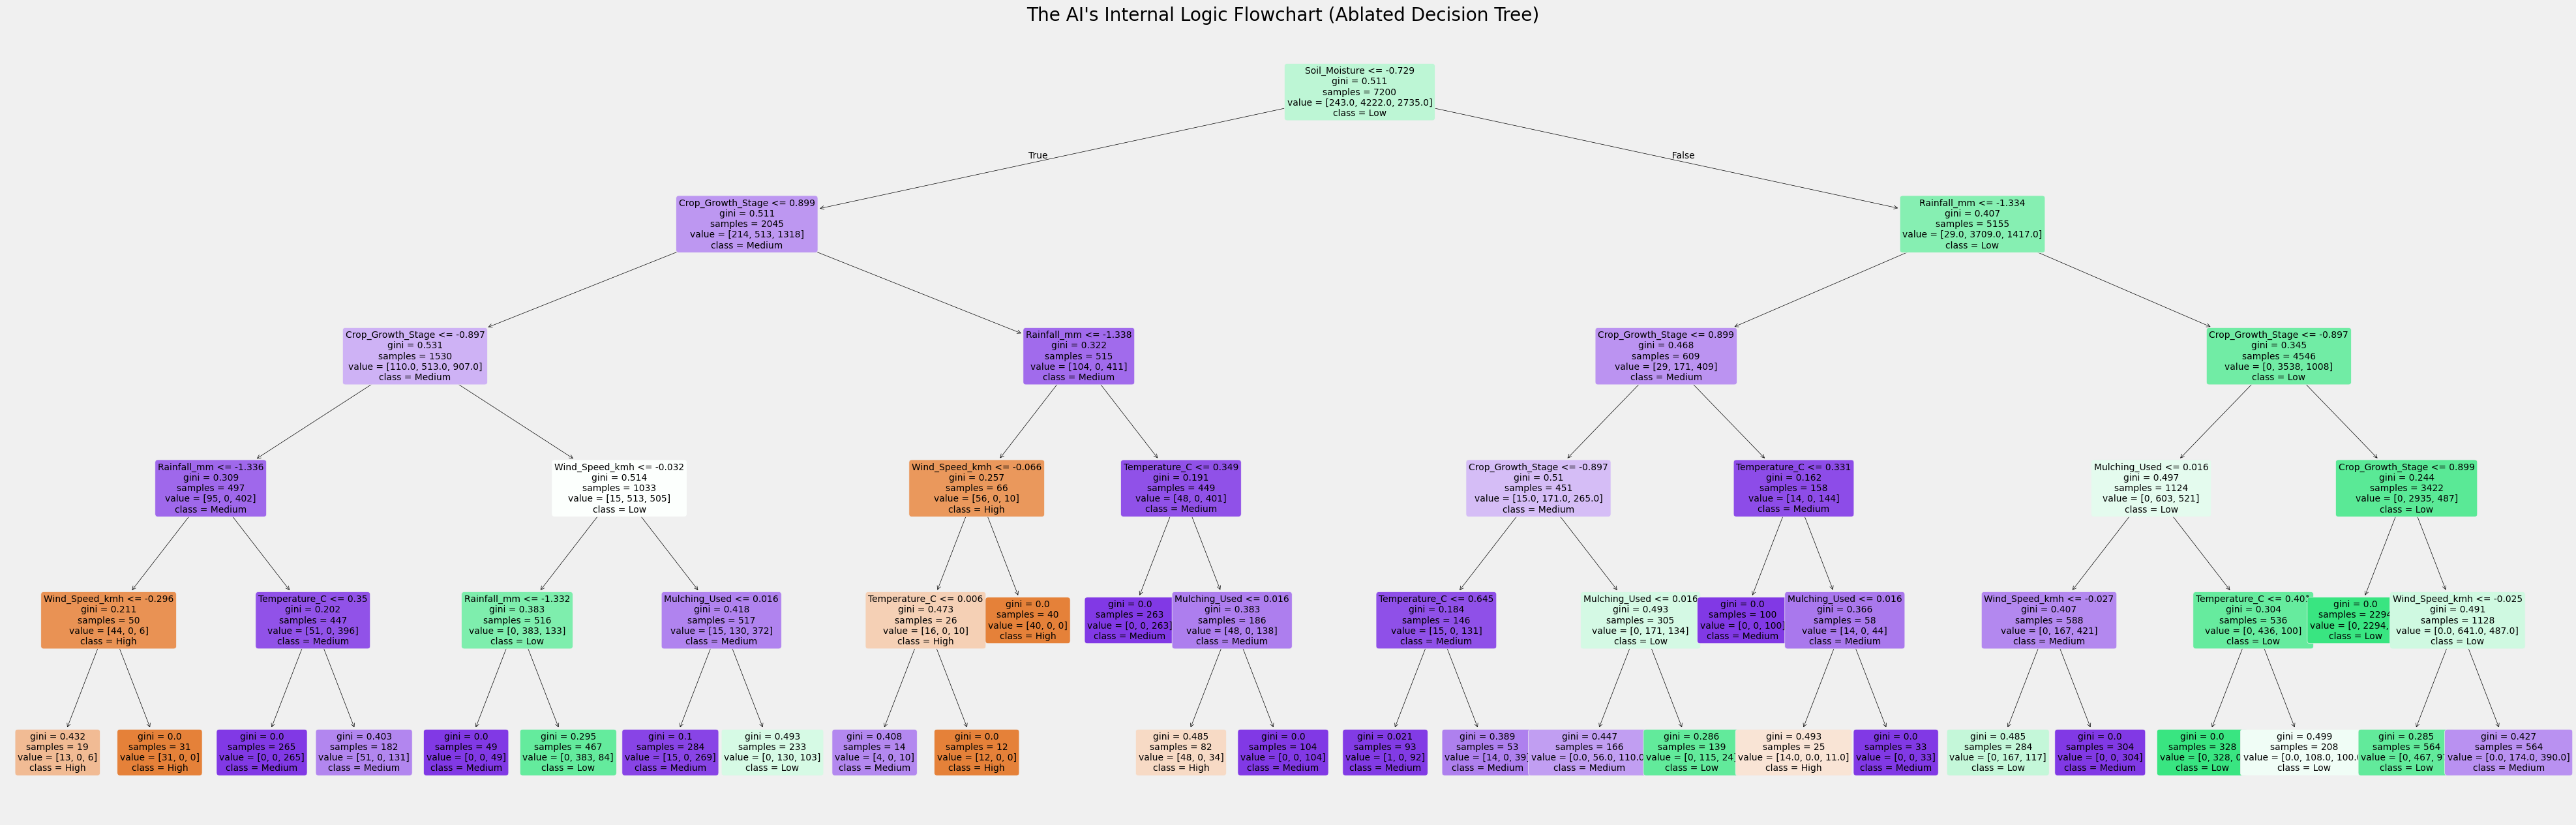

In [31]:
from sklearn.tree import plot_tree
if "Decision Tree" in models_to_test:
    plt.figure(figsize=(45, 15))
    plot_tree(models_to_test["Decision Tree"], 
              feature_names=ablated_features, 
              class_names=label_encoders[target_col].classes_,
              filled=True, 
              rounded=True, fontsize=10)
    plt.title("The AI's Internal Logic Flowchart (Ablated Decision Tree)")
    plt.show()